# 📊 Sales Data Analysis using SQL and Python

## 📖 Project Overview

This project focuses on analyzing retail sales data using **SQLite, SQL, Python, and Pandas**. The objective is to extract meaningful business insights by performing SQL queries on a structured database and analyzing the results using Python.

The project demonstrates essential Data Analyst skills, including:

- Database creation using SQLite
- SQL querying and data retrieval
- Data analysis with Pandas
- Business insight generation
- Professional documentation

---

## 🎯 Project Objectives

- Create a SQLite database from a CSV dataset.
- Retrieve business information using SQL queries.
- Analyze sales performance and customer behavior.
- Generate business insights from the data.
- Build a professional portfolio project for GitHub and LinkedIn.

---

## 🛠️ Technologies Used

- Python
- SQLite
- SQL
- Pandas
- Jupyter Notebook

# Section 1: SQL Analysis

📥 Import Required Libraries

The following libraries are used throughout the project:

- **Pandas** → Data analysis and manipulation
- **SQLite3** → Database connection and SQL execution

In [1]:
import pandas as pd
import sqlite3

# 🔗 Connect to SQLite Database

In this step, we establish a connection with the SQLite database created using DB Browser for SQLite.

Once connected, Python can execute SQL queries directly on the database.

In [3]:
conn = sqlite3.connect("../database/superstore.db")

print("Database Connected Successfully!")

Database Connected Successfully!


# 📂 Verify Available Tables

Before performing any SQL analysis, it is important to verify that the required table has been successfully imported into the database.

This step retrieves all available tables from the SQLite database.

In [4]:
query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,superstore


# 👀 Preview the Dataset

Before starting the analysis, it is important to inspect the data stored in the database.

This step retrieves the first 10 records from the **superstore** table to understand the structure of the dataset and verify that the data has been imported correctly.

In [5]:
query = """
SELECT *
FROM superstore
LIMIT 10;
"""

df = pd.read_sql(query, conn)

df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


## 📌 Observation

The dataset has been successfully retrieved from the SQLite database.

The preview confirms that the dataset contains order details such as:

- Order ID
- Order Date
- Customer Information
- Product Details
- Sales
- Quantity
- Discount
- Profit

The data appears to be structured correctly and is ready for further analysis.

# 📊 Determine the Total Number of Records

Before performing detailed analysis, it is important to know the total number of records available in the database.

This helps in understanding the size of the dataset and validates that all records were imported successfully.

In [6]:
query = """
SELECT COUNT(*) AS Total_Records
FROM superstore;
"""

pd.read_sql(query, conn)

,Total_Records
0,9994


## 💼 Business Insight

The database contains **9,994 sales records**, providing sufficient data to perform meaningful business analysis.

A dataset of this size enables the identification of sales trends, customer purchasing behavior, product performance, and regional business insights.

# 📈 Business Key Performance Indicators (KPIs)

Key Performance Indicators (KPIs) provide a quick overview of business performance.

In this section, we will calculate important business metrics such as:

- Total Sales
- Total Profit
- Total Orders
- Total Customers
- Total Products

These KPIs help stakeholders understand the overall performance of the business before performing detailed analysis.

In [10]:
query = """
SELECT
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Total_Orders,
    COUNT(DISTINCT "Customer ID") AS Total_Customers,
    COUNT(DISTINCT "Product ID") AS Total_Products
FROM superstore;   
"""
kpi = pd.read_sql(query, conn)

kpi


,Total_Sales,Total_Profit,Total_Orders,Total_Customers,Total_Products
0,2297200.86,286397.02,5009,793,1862


## 📊 Business Insight

The calculated KPIs provide a high-level summary of the company's overall business performance.

Key observations include:

- Total revenue generated by the company.
- Overall profit earned from all sales transactions.
- Total number of unique customer orders.
- Number of customers served.
- Number of unique products sold.

These KPIs serve as the foundation for deeper business analysis, helping decision-makers evaluate overall business health and identify opportunities for improvement.

# 📦 Sales Performance by Category

Different product categories contribute differently to the company's revenue.

In this analysis, we calculate total sales and total profit generated by each product category.

This helps identify the highest-performing categories and supports strategic business decisions such as inventory planning and marketing investments.

In [11]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

category_sales = pd.read_sql(query, conn)

category_sales

,Category,Total_Sales,Total_Profit
0,Technology,836154.03,145454.95
1,Furniture,741999.80,18451.27
2,Office Supplies,719047.03,122490.80


## 💼 Business Insight

The category-wise analysis highlights which product categories generate the highest sales and profit.

Understanding category performance enables businesses to:

- Allocate inventory efficiently.
- Focus marketing efforts on high-performing categories.
- Improve profitability by optimizing low-performing categories.
- Support strategic business planning through data-driven decisions.

# 📊 Category-wise Sales Visualization

Visualizing sales data makes it easier to compare the performance of different product categories.

The following bar chart represents the total sales generated by each category.

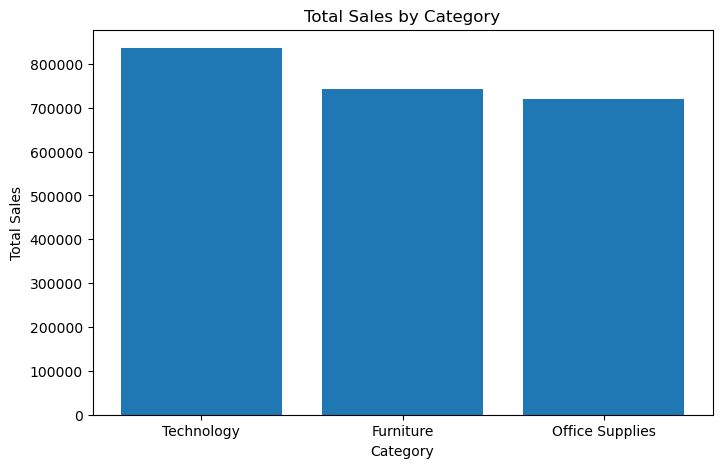

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(category_sales["Category"], category_sales["Total_Sales"])

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Save the chart
plt.savefig("../images/category_sales.png", dpi=300, bbox_inches="tight")

plt.show()

## 💼 Business Insight

The visualization clearly highlights the sales contribution of each product category.

Higher sales indicate categories that attract more customer demand, while lower-performing categories may require additional marketing efforts or product strategy improvements.

# 🌍 Sales Performance by Region

Regional analysis helps businesses understand which geographical areas contribute the most to overall sales.

This information supports business expansion, inventory planning, and regional marketing strategies.

In [13]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

region_sales = pd.read_sql(query, conn)

region_sales

,Region,Total_Sales,Total_Profit
0,West,725457.82,108418.45
1,East,678781.24,91522.78
2,Central,501239.89,39706.36
3,South,391721.91,46749.43


## 📊 Observation

The table displays the total sales and profit generated from each region.

Comparing regional performance helps identify high-performing markets and regions that may require additional business focus.

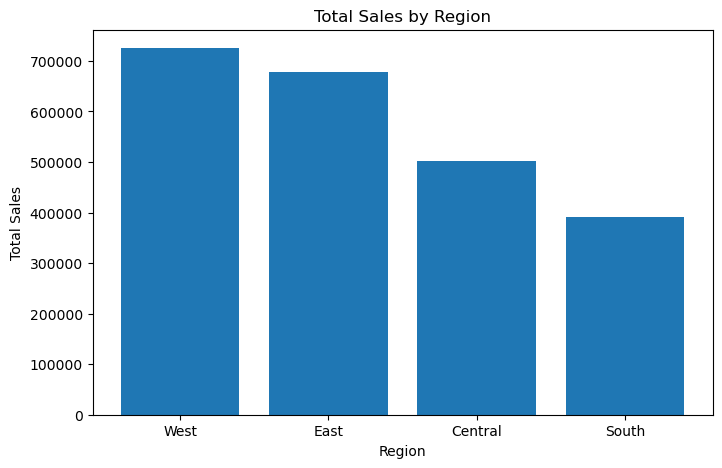

In [16]:
plt.figure(figsize=(8,5))

plt.bar(region_sales["Region"], region_sales["Total_Sales"])

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

# Save the chart
plt.savefig("../images/region_sales.png", dpi=300, bbox_inches="tight")

plt.show()

📊 Sales Data Analysis using SQL and Python

✔ Project Overview
✔ Import Libraries
✔ Database Connection
✔ Verify Tables
✔ Dataset Preview
✔ Total Records
✔ Business KPIs
✔ Category Analysis
✔ Category Chart
✔ Region Analysis
✔ Region Chart

# 👥 Top 10 Customers by Sales

Identifying high-value customers is an important part of business analysis.

This analysis retrieves the top 10 customers based on total sales. Understanding customer purchasing behavior helps businesses build customer loyalty programs and improve revenue.

In [17]:
query = """
SELECT
    "Customer Name",
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM superstore
GROUP BY "Customer Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, conn)

top_customers

,Customer Name,Total_Sales
0,Sean Miller,25043.05
1,Tamara Chand,19052.22
2,Raymond Buch,15117.34
3,Tom Ashbrook,14595.62
4,Adrian Barton,14473.57
5,Ken Lonsdale,14175.23
6,Sanjit Chand,14142.33
7,Hunter Lopez,12873.30
8,Sanjit Engle,12209.44
9,Christopher Conant,12129.07


## 📊 Observation

The table lists the top 10 customers based on total sales.

These customers contribute significantly to the company's revenue and can be considered high-value customers.

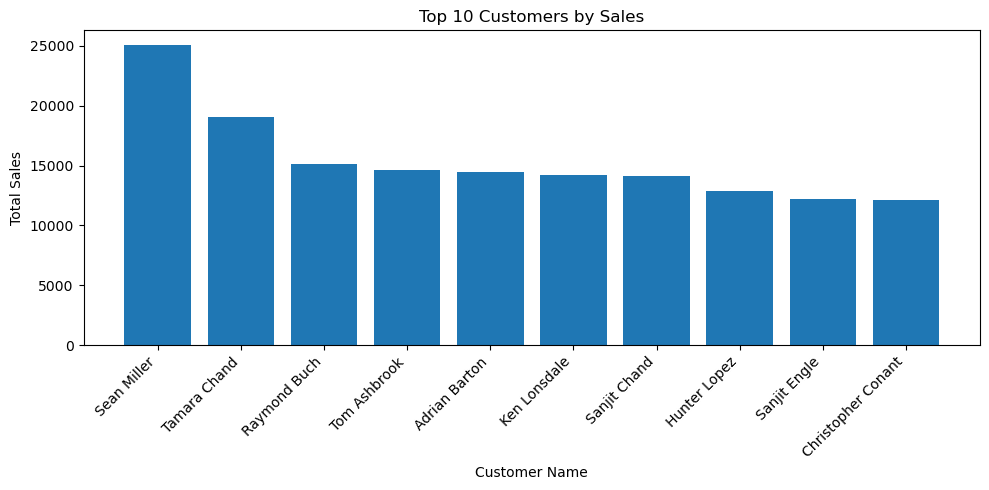

In [18]:
plt.figure(figsize=(10,5))

plt.bar(top_customers["Customer Name"], top_customers["Total_Sales"])

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Save the chart
plt.savefig("../images/top10_customers.png", dpi=300, bbox_inches="tight")

plt.show()

## 💼 Business Insight

The analysis identifies the company's highest-value customers based on total sales.

These customers are important for business growth and should be targeted through personalized marketing campaigns, loyalty programs, and premium customer services to increase customer retention and long-term revenue.

# 📦 Top 10 Products by Sales

Product-level analysis helps identify the best-performing products based on total sales.

By identifying top-selling products, businesses can optimize inventory management, improve marketing strategies, and maximize overall revenue.

In [19]:
query = """
SELECT
    "Product Name",
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM superstore
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, conn)

top_products

,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48
3,HON 5400 Series Task Chairs for Big and Tall,21870.58
4,GBC DocuBind TL300 Electric Binding System,19823.48
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.50
6,Hewlett Packard LaserJet 3310 Copier,18839.69
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.90
8,GBC DocuBind P400 Electric Binding System,17965.07
9,High Speed Automatic Electric Letter Opener,17030.31


## 📊 Observation

The table displays the top 10 products with the highest sales.

These products generate significant revenue and represent the company's best-selling items.

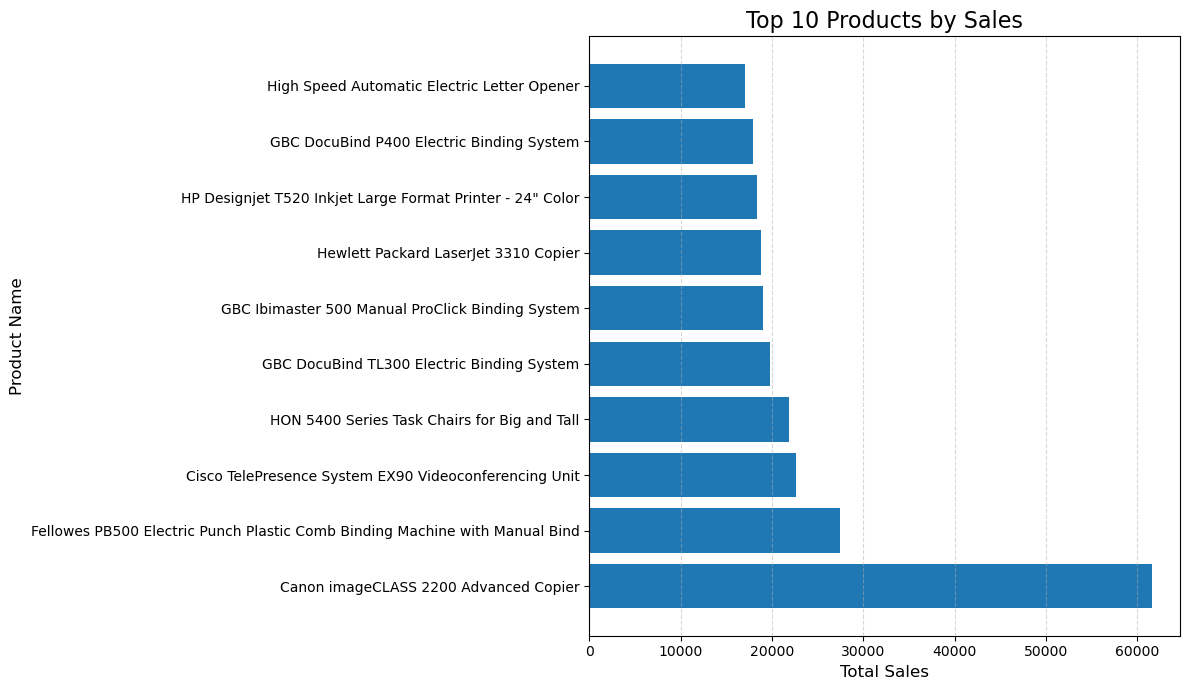

In [22]:
plt.figure(figsize=(12,7))

plt.barh(top_products["Product Name"], top_products["Total_Sales"])

plt.title("Top 10 Products by Sales", fontsize=16)
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("../images/top10_products.png", dpi=300, bbox_inches="tight")

plt.show()

## 💼 Business Insight

The top-performing products contribute a significant portion of the company's total revenue.

Businesses should ensure these products remain well-stocked, maintain competitive pricing, and prioritize them in promotional campaigns to maximize profitability and customer satisfaction.

# 🗺️ State-wise Sales Analysis

State-wise sales analysis helps identify the geographical regions that generate the highest revenue.

This analysis enables businesses to understand regional performance, optimize resource allocation, and support strategic expansion decisions.

In [31]:
query = """
SELECT
    State,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM superstore
GROUP BY State
ORDER BY Total_Sales DESC
LIMIT 10;
"""

state_sales = pd.read_sql(query, conn)

state_sales

,State,Total_Sales
0,California,457687.63
1,New York,310876.27
2,Texas,170188.05
3,Washington,138641.27
4,Pennsylvania,116511.91
5,Florida,89473.71
6,Illinois,80166.10
7,Ohio,78258.14
8,Michigan,76269.61
9,Virginia,70636.72


## 📊 Observation

The table displays the top 10 states based on total sales.

These states contribute the highest revenue and represent the company's strongest markets.

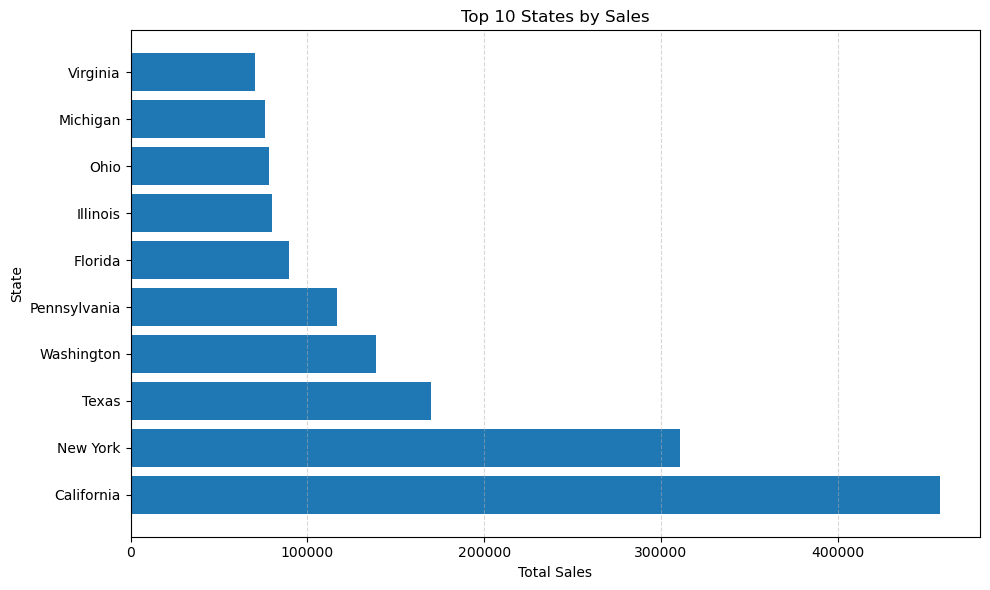

In [32]:
plt.figure(figsize=(10,6))

plt.barh(state_sales["State"], state_sales["Total_Sales"])

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("../images/top10_states.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## 💼 Business Insight

The state-wise analysis highlights the regions generating the highest sales revenue.

These high-performing states present opportunities for business expansion, customer retention, and targeted marketing initiatives.

# 💰 Profit Analysis by Category

Profit analysis helps identify which product categories contribute the most to the company's profitability.

While high sales are important, high profit is a better indicator of business success. This analysis compares total profit across different product categories.

In [33]:
query = """
SELECT
    Category,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

profit_category = pd.read_sql(query, conn)

profit_category

,Category,Total_Profit
0,Technology,145454.95
1,Office Supplies,122490.80
2,Furniture,18451.27


## 📊 Observation

The table displays the total profit generated by each product category.

Comparing category-wise profit helps identify the most profitable business segments.

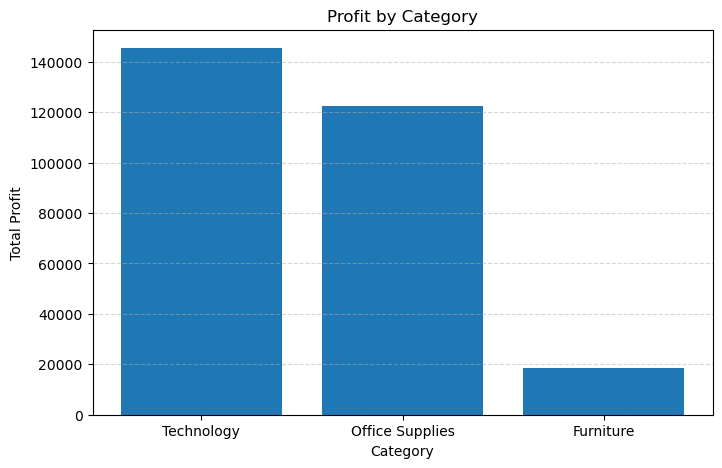

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    profit_category["Category"],
    profit_category["Total_Profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../images/profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 💼 Business Insight

The profit analysis reveals which product categories generate the highest earnings for the company.

Categories with high profit should be prioritized for inventory management and marketing, while low-profit categories should be reviewed to improve pricing strategies, reduce operational costs, or optimize product offerings.

# 🎁 Discount Analysis by Category

Discounts are commonly offered to attract customers and increase sales. However, excessive discounts can reduce profitability.

This analysis examines the average discount provided across different product categories.

In [35]:
query = """
SELECT
    Category,
    ROUND(AVG(Discount), 2) AS Average_Discount
FROM superstore
GROUP BY Category
ORDER BY Average_Discount DESC;
"""

discount_analysis = pd.read_sql(query, conn)

discount_analysis

,Category,Average_Discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


## 📊 Observation

The table shows the average discount offered for each product category.

Comparing discount levels helps identify categories where pricing strategies may impact profitability.

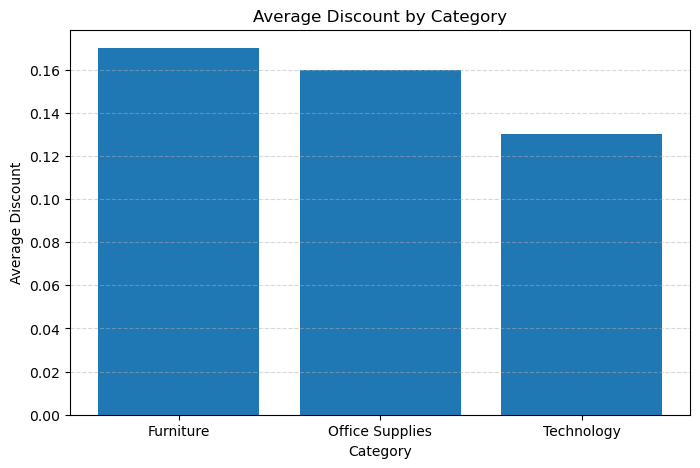

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    discount_analysis["Category"],
    discount_analysis["Average_Discount"]
)

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig(
    "../images/discount_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 💼 Business Insight

The discount analysis highlights the average discounts offered across product categories.

Categories with higher average discounts should be regularly monitored to ensure that promotional strategies increase sales without significantly reducing overall profitability.

# 📋 Final Business Insights

Based on the SQL analysis, the following key business insights were identified:

1. The company generated strong overall sales and profit across multiple product categories.

2. Technology emerged as one of the highest revenue-generating categories.

3. Sales performance varied across different regions, highlighting geographical differences in business performance.

4. A small group of customers contributed significantly to total sales, indicating valuable repeat customers.

5. A few products accounted for a large share of total revenue.

6. Certain states consistently generated higher sales than others, making them key target markets.

7. Profitability differed across product categories, suggesting opportunities to optimize product strategy.

8. Discount levels varied between categories and should be monitored to maintain healthy profit margins.

Overall, the analysis provides valuable insights that can support data-driven business decisions related to marketing, inventory management, pricing, and regional expansion.

# 📝 Conclusion

This project demonstrates the use of SQL (SQLite) and Python for retail sales data analysis.

Using SQL queries, key business metrics such as sales, profit, customer performance, regional performance, product performance, and discount analysis were explored.

The project showcases practical data analysis skills including SQL querying, database management, data visualization, and business insight generation.

Overall, this analysis highlights how data can support better business decision-making and strategic planning.

# Section 2: Python Data Analysis

This section uses Python and Pandas to perform advanced data preprocessing and time-based analysis. Since SQLite cannot directly process the dataset's date format, Python is used to convert dates and generate yearly and monthly sales trends.

# 📅 Data Preparation

Before performing time-series analysis, the `Order Date` column needs to be converted into a proper datetime format. This allows us to extract useful information such as year and month for trend analysis.

In [37]:
# Load the complete dataset from SQLite

sales_df = pd.read_sql("SELECT * FROM superstore", conn)

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [38]:
# Check data types

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 📊 Observation

The `Order Date` column is stored as text (object). It must be converted into a datetime format before performing year-wise or month-wise analysis.

In [39]:
# Convert Order Date to datetime

sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    format="%m/%d/%Y"
)

sales_df["Order Date"].head()

0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[ns]

In [40]:
# Extract Year and Month

sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month_name()

sales_df[["Order Date", "Year", "Month"]].head()

,Order Date,Year,Month
0,2016-11-08,2016,November
1,2016-11-08,2016,November
2,2016-06-12,2016,June
3,2015-10-11,2015,October
4,2015-10-11,2015,October


## 📊 Observation

The `Order Date` column has been successfully converted into the datetime format.

Two new columns, `Year` and `Month`, were created to support time-based analysis such as yearly and monthly sales trends.

# 📈 Year-wise Sales Trend

Year-wise sales analysis helps understand how the company's sales performance has changed over time.

This analysis identifies growth patterns and supports long-term business planning.

In [41]:
# Calculate yearly sales

yearly_sales = sales_df.groupby("Year")["Sales"].sum().reset_index()

yearly_sales

,Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


## 📊 Observation

The table displays the total sales generated in each year.

Comparing yearly sales helps identify overall business growth and performance trends over time.

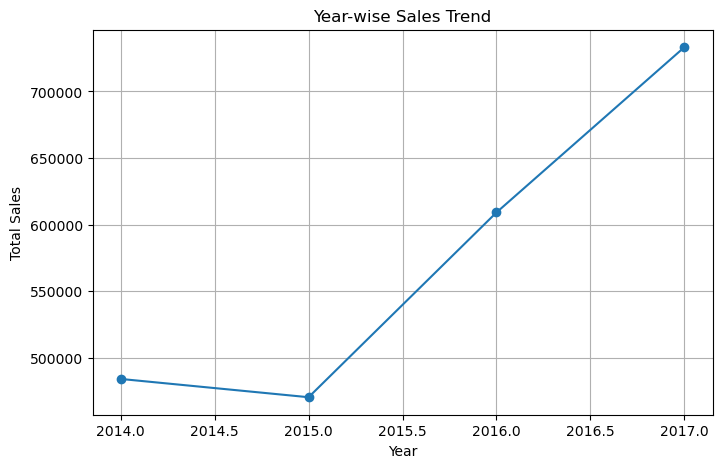

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly_sales["Year"],
    yearly_sales["Sales"],
    marker="o"
)

plt.title("Year-wise Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(True)

plt.savefig(
    "../images/yearly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 💼 Business Insight

The year-wise sales trend shows how the company's revenue has changed over the years.

An increasing sales trend indicates business growth, while any decline may highlight periods that require further investigation to improve performance.

# 📅 Monthly Sales Trend

Monthly sales analysis helps identify seasonal trends and monthly sales patterns.

Understanding monthly performance enables businesses to plan inventory, marketing campaigns, and promotional activities more effectively.

In [43]:
# Create Month Number for correct ordering

sales_df["Month_Number"] = sales_df["Order Date"].dt.month

monthly_sales = (
    sales_df.groupby(["Month_Number", "Month"])["Sales"]
    .sum()
    .reset_index()
    .sort_values("Month_Number")
)

monthly_sales

,Month_Number,Month,Sales
0,1,January,94924.8356
1,2,February,59751.2514
2,3,March,205005.4888
3,4,April,137762.1286
4,5,May,155028.8117
5,6,June,152718.6793
6,7,July,147238.0970
7,8,August,159044.0630
8,9,September,307649.9457
9,10,October,200322.9847


## 📊 Observation

The table shows the total sales for each month.

Using the month number ensures that the months are displayed in chronological order from January to December.

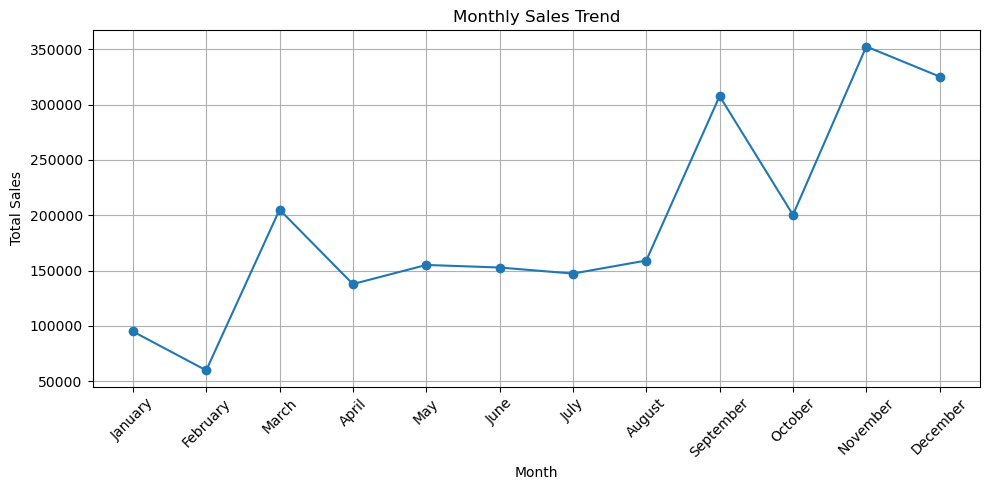

In [44]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../images/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 💼 Business Insight

The monthly sales trend helps identify periods of high and low demand throughout the year.

Businesses can use this information to optimize inventory levels, schedule marketing campaigns, and improve sales planning during seasonal peaks and slower months.

# 📊 Sales vs Profit Analysis

This analysis examines the relationship between sales and profit.

A scatter plot helps identify whether higher sales always result in higher profits and highlights any unusual patterns or outliers.

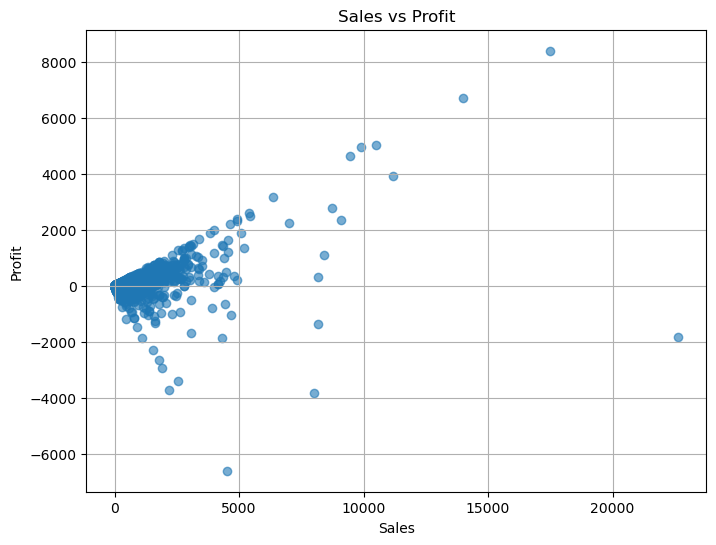

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    sales_df["Sales"],
    sales_df["Profit"],
    alpha=0.6
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(True)

plt.savefig(
    "../images/sales_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📊 Observation

The scatter plot illustrates the relationship between sales and profit for individual transactions.

While many high-sales transactions generate higher profits, some transactions show low or even negative profits despite high sales, indicating the impact of discounts or other business factors.

## 💼 Business Insight

The relationship between sales and profit is not always directly proportional.

Some high-value sales produce low or negative profits, suggesting that discount strategies and pricing policies should be carefully monitored to improve overall profitability.